# Umubyeyi 
### A Kinyarwanda AI Chatbot Supporting Maternal Mental Wellbeing for First-Time Mothers in Rwanda

**Author:** Raissa IRUTINGABO · **Supervisor:** Samiratu Ntohsi · BSc Software Engineering


#### The system in one line
A mother types in Kinyarwanda → NLLB-200 translates to English → a TF-IDF + ML classifier routes the
message to one of 6 maternal-wellness intents → the intent selects one of six guideline-sourced
response templates → translated back to Kinyarwanda → shown with a safety disclaimer.

In [1]:

import warnings, re, json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 90)
RNG = 42

# brand palette
TEAL, CORAL, SAND = "#2A9D8F", "#E76F51", "#E9C46A"
INTENT_PALETTE = ["#2A9D8F", "#E76F51", "#E9C46A", "#264653", "#8AB17D", "#F4A261"]

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
print("Project root:", ROOT)

Project root: C:\Users\pc\Desktop\UMUBYEYI


## 1. Data loading

The classifier is trained on **`Amod/mental;health;counseling;conversations`** 3,512 real Q&A pairs between people and licensed counselors (`Context` = the person's message, `Response` = the counselor's reply). We load from the cached CSV produced by `src/eda.py`, falling back to Hugging Face.

In [2]:
raw_csv = ROOT / "data" / "raw" / "amod_full.csv"
if raw_csv.exists():
    df = pd.read_csv(raw_csv)
else:
    from datasets import load_dataset
    df = load_dataset("Amod/mental_health_counseling_conversations")["train"].to_pandas()
df.columns = [c.strip() for c in df.columns]
print(f"Loaded {len(df):,} rows | columns: {list(df.columns)}")
df.head(3)

Loaded 3,512 rows | columns: ['Context', 'Response']


,Context,Response
0,I'm going through some things with my feelings and myself. I barely sleep and I do not...,"If everyone thinks you're worthless, then maybe you need to find new people to hang ou..."
1,I'm going through some things with my feelings and myself. I barely sleep and I do not...,"Hello, and thank you for your question and seeking advice on this. Feelings of worthle..."
2,I'm going through some things with my feelings and myself. I barely sleep and I do not...,First thing I'd suggest is getting the sleep you need or it will impact how you think ...


## 2. Data engineering & cleaning

Steps:
1. **Trim & drop empties** strip whitespace, remove rows with an empty `Context` or `Response`.
2. **Engineer length features** word/character counts (used for visualization and as a data-quality check).
3. **Audit duplicates** a critical finding: the 3,512 rows contain far fewer *unique* questions.
4. **De-duplicate for classification** the classifier's input is `Context` only, so identical questions are collapsed to avoid train/test leakage and double-counting.

In [3]:
# 2.1 trim + drop empties
for c in ["Context", "Response"]:
    df[c] = df[c].astype(str).str.strip()
before = len(df)
df = df[(df["Context"].str.len() > 0) & (df["Response"].str.len() > 0)].copy()
print(f"Dropped {before - len(df)} empty rows -> {len(df):,} remain")

# 2.2 length features
wc = lambda t: len(re.findall(r"\b\w+\b", str(t)))
df["ctx_words"]  = df["Context"].map(wc)
df["resp_words"] = df["Response"].map(wc)
df["ctx_chars"]  = df["Context"].str.len()
df["resp_chars"] = df["Response"].str.len()
df[["ctx_words", "resp_words", "ctx_chars", "resp_chars"]].describe().round(1)

Dropped 0 empty rows -> 3,512 remain


,ctx_words,resp_words,ctx_chars,resp_chars
count,3512.0,3512.0,3512.0,3512.0
mean,57.5,183.5,282.7,1025.9
std,50.2,129.3,246.2,1010.8
min,5.0,1.0,24.0,1.0
25%,30.0,98.0,147.0,532.0
50%,48.0,150.0,232.0,836.0
75%,71.0,229.0,348.2,1271.8
max,556.0,2043.0,2703.0,32739.0


In [4]:
# 2.3 duplicate audit
n_unique = df["Context"].nunique()
print(f"Total rows ............ {len(df):,}")
print(f"UNIQUE questions ...... {n_unique:,}")
print(f"Duplicate-question rows {df['Context'].duplicated().sum():,}  (same question, different counselor answers)")
print(f"Fully duplicate pairs . {df.duplicated(['Context','Response']).sum():,}")
print("\n=> For INTENT CLASSIFICATION the input is the question only, so we de-duplicate on Context.")

Total rows ............ 3,512
UNIQUE questions ...... 995
Duplicate-question rows 2,517  (same question, different counselor answers)
Fully duplicate pairs . 1,041

=> For INTENT CLASSIFICATION the input is the question only, so we de-duplicate on Context.


In [5]:
# 2.4 de-duplicate to unique questions (keep first answer)
dfu = df.drop_duplicates(subset="Context", keep="first").reset_index(drop=True)
print(f"Unique-question dataset for modeling: {len(dfu):,} rows")

Unique-question dataset for modeling: 995 rows


### 2.5 Intent labeling

The six maternal-wellness intents are defined by a transparent keyword lexicon. Each question is scored
per intent by keyword hits and assigned the highest-scoring intent. Questions matching an exclusion
topic (addiction, PTSD, eating disorders, etc.) or matching no intent are dropped as out of scope.

Tie-breaking favors rarer intents (lexicon ordered rare to common) to slightly counter class imbalance.

In [6]:
# lexicon ordered rare -> common so argmax ties favor rarer classes
INTENT_KEYWORDS = {
    "self_care_coping":     ["self-care", "self care", "coping", "cope", "manage", "routine", "advice", "what can i do", "take care"],
    "sleep":                ["sleep", "insomnia", "tired", "exhaust", "awake", "rest", "fatigue"],
    "overwhelmed_identity": ["overwhelm", "myself", "identity", "lost", "failing", "failure", "too much", "can't handle"],
    "sadness_low_mood":     ["sad", "depress", "empty", "hopeless", "tearful", "cry", "worthless", "down", "numb", "miserable"],
    "anxiety_worry":        ["anxi", "worry", "worried", "panic", "afraid", "fear", "nervous", "scared", "stress"],
    "relationship_support": ["partner", "husband", "wife", "family", "relationship", "alone", "lonely", "support", "marriage", "friend"],
}
EXCLUDE = ["childhood trauma", "addict", "alcohol", "drug", "eating disorder", "anorexia",
           "bulimia", "ptsd", "flashback", "personality disorder", "schizophren", "bipolar"]

ctx = dfu["Context"].str.lower()
intents = list(INTENT_KEYWORDS)
hits = pd.DataFrame({i: ctx.str.contains("|".join(re.escape(k) for k in kws), regex=True)
                     for i, kws in INTENT_KEYWORDS.items()}).astype(int)
dfu["excluded"] = ctx.str.contains("|".join(re.escape(k) for k in EXCLUDE), regex=True)
dfu["n_intents"] = hits.sum(axis=1)

# assign label = argmax keyword hits (ties -> rarer intent via column order); 0-hit or excluded -> drop
label_idx = hits.values.argmax(axis=1)
dfu["intent"] = [intents[j] for j in label_idx]
dfu.loc[(dfu["n_intents"] == 0) | (dfu["excluded"]), "intent"] = np.nan

data = dfu.dropna(subset=["intent"]).reset_index(drop=True)
print(f"Labeled, in-scope dataset: {len(data):,} questions across {data['intent'].nunique()} intents")

Labeled, in-scope dataset: 724 questions across 6 intents


In [7]:
# class distribution
dist = data["intent"].value_counts()
print(dist.to_string())
print(f"\nImbalance ratio (max/min): {dist.max()/dist.min():.1f}x  -> F1 is the right headline metric")

intent
relationship_support    230
overwhelmed_identity    137
sadness_low_mood        121
sleep                    84
self_care_coping         76
anxiety_worry            76

Imbalance ratio (max/min): 3.0x  -> F1 is the right headline metric


## 3. Data visualization

### 3.1 Text-length distributions
How long are the questions the model must classify, and the answers behind each intent?

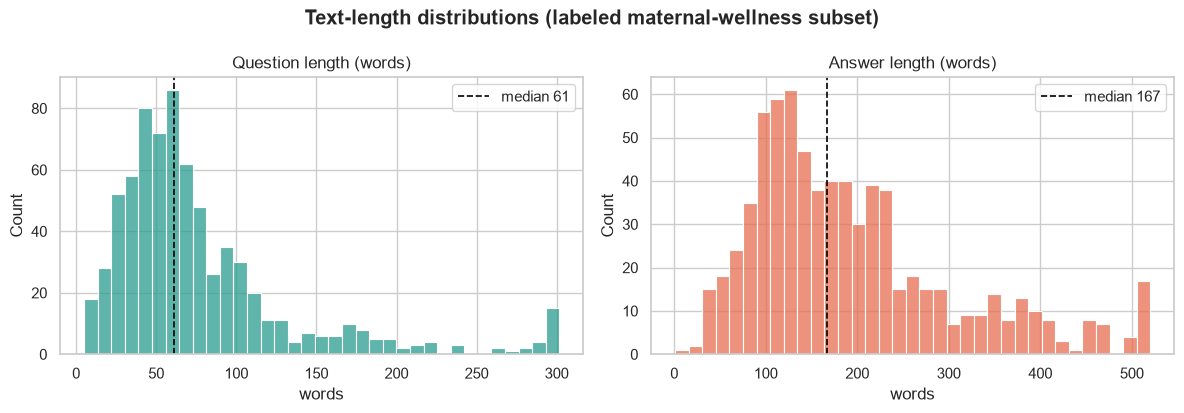

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for a, col, color, t in [(ax[0], "ctx_words", TEAL, "Question length (words)"),
                         (ax[1], "resp_words", CORAL, "Answer length (words)")]:
    d = data[col].clip(upper=data[col].quantile(0.98))
    sns.histplot(d, bins=35, color=color, edgecolor="white", ax=a)
    a.axvline(data[col].median(), color="black", ls="--", lw=1.2, label=f"median {data[col].median():.0f}")
    a.set_title(t); a.set_xlabel("words"); a.legend()
fig.suptitle("Text-length distributions (labeled maternal-wellness subset)", fontweight="bold")
fig.tight_layout(); plt.show()

**Read:** questions are short (median ~45 words) ideal for TF-IDF. Answers are longer and more variable, which is why responses come from fixed, guideline-sourced response templates (one per intent) rather than being generated.

### 3.2 Intent class balance
The single most important modeling fact: the classes are **imbalanced**.

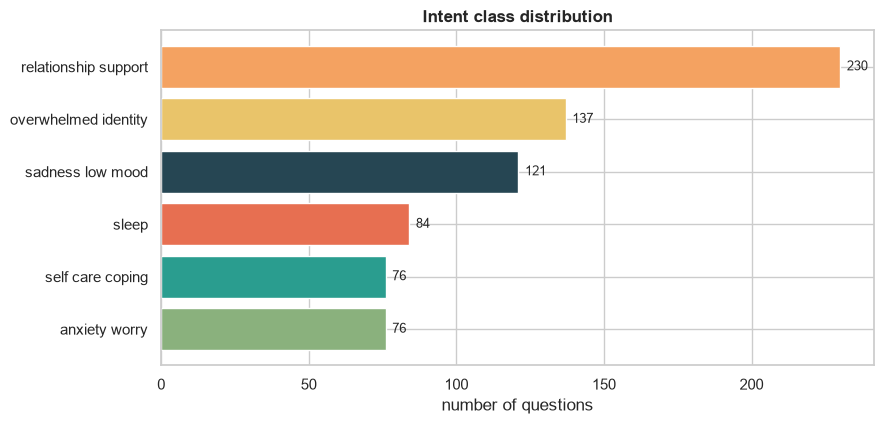

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.4))
order = dist.sort_values().index
ax.barh(range(len(order)), dist[order].values,
        color=[INTENT_PALETTE[intents.index(i)] for i in order])
ax.set_yticks(range(len(order))); ax.set_yticklabels([i.replace("_", " ") for i in order])
for y, v in enumerate(dist[order].values):
    ax.text(v + dist.max()*0.01, y, f"{v:,}", va="center", fontsize=9)
ax.set_title("Intent class distribution", fontweight="bold")
ax.set_xlabel("number of questions"); fig.tight_layout(); plt.show()

**Implication:** *relationship/support* dominates and *self-care* / *sleep* are thin. We mitigate this with `class;weight='balanced'` during training and report **macro-F1** (averages classes equally) instead of plain accuracy (which a majority-class guesser can inflate).

### 3.3 Feature correlations
Correlation among the engineered numeric features a quick data-quality sanity check.

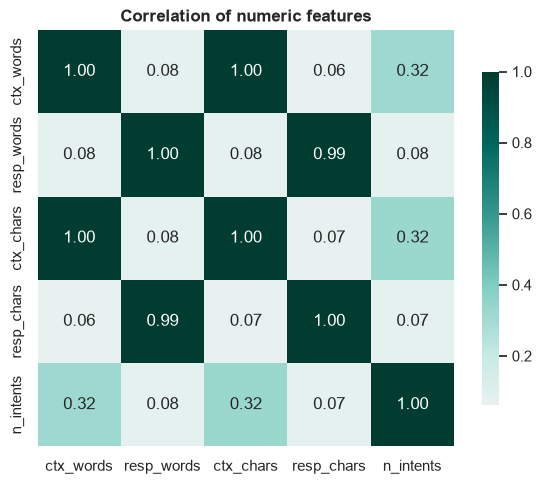

In [10]:
num = data[["ctx_words", "resp_words", "ctx_chars", "resp_chars", "n_intents"]]
fig, ax = plt.subplots(figsize=(6.2, 5))
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="BrBG", center=0,
            square=True, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Correlation of numeric features", fontweight="bold")
fig.tight_layout(); plt.show()

**Read:** word- and character-counts correlate almost perfectly (expected they measure the same thing), so only one length feature is informative. Question length and answer length are only weakly related: a short question can have a long answer. `n;intents` is largely independent of length longer questions don't necessarily touch more topics.

### 3.4 Most distinctive words per intent
The terms that most characterize each intent i.e. what the TF-IDF classifier keys on.

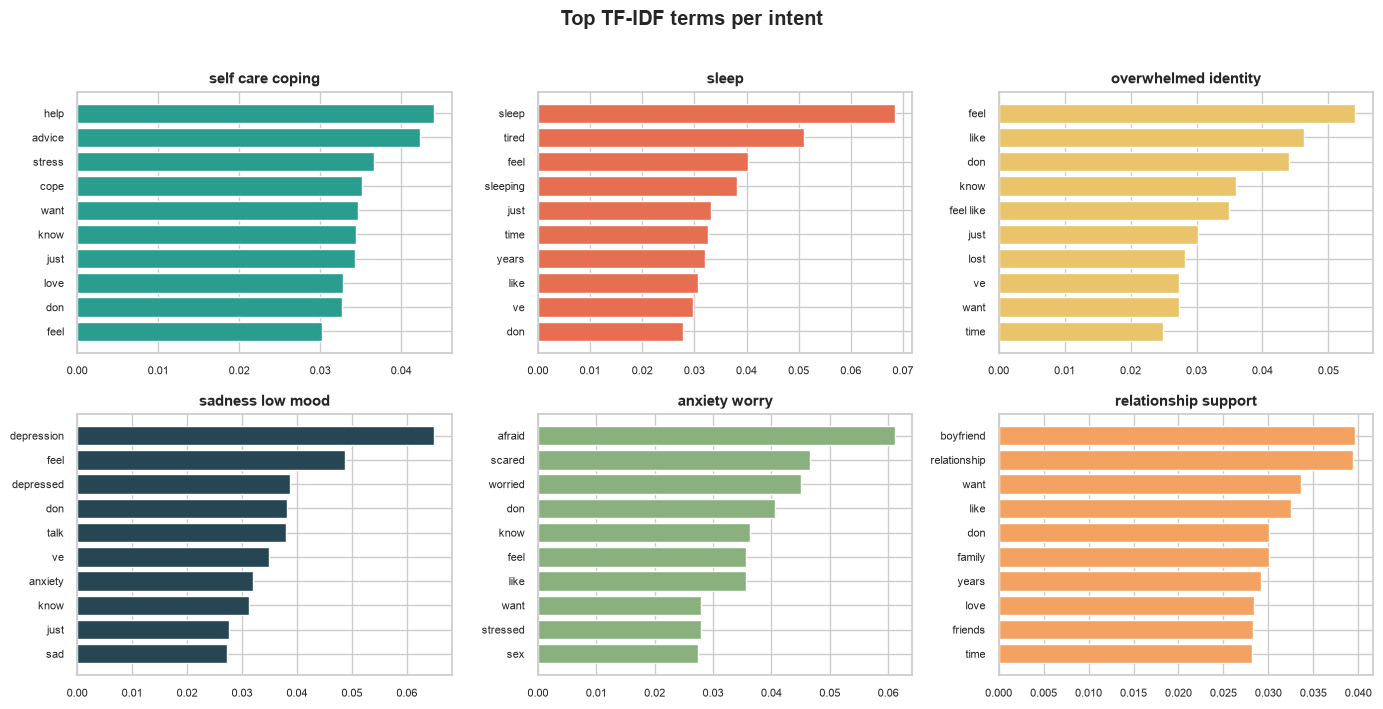

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
viz_tfidf = TfidfVectorizer(stop_words="english", ngram_range=(1, 2),
                            min_df=3, max_features=4000, sublinear_tf=True)
Xv = viz_tfidf.fit_transform(data["Context"])
terms = np.array(viz_tfidf.get_feature_names_out())

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, intent in zip(axes.ravel(), intents):
    mask = (data["intent"] == intent).values
    mean_tfidf = np.asarray(Xv[mask].mean(axis=0)).ravel()
    top = mean_tfidf.argsort()[-10:]
    ax.barh(terms[top], mean_tfidf[top], color=INTENT_PALETTE[intents.index(intent)])
    ax.set_title(intent.replace("_", " "), fontsize=11, fontweight="bold")
    ax.tick_params(labelsize=8)
fig.suptitle("Top TF-IDF terms per intent", fontweight="bold", y=1.01)
fig.tight_layout(); plt.show()

**Read:** terms align with intuition (e.g. *sleep / tired* for sleep; *partner / relationship* for relationship-support), confirming that the questions carry clear, intent-distinguishing vocabulary for the classifier to key on.

## 4. Feature engineering & train/test split

- **Features:** TF-IDF over unigrams+bigrams, English stop-words removed, sublinear term-frequency scaling, `min;df=2`, capped at 8,000 features a sparse, low-compute representation suited to deployment without a GPU.
- **Split:** stratified 80/20 (preserves class proportions). Because we already de-duplicated on `Context`, no question can appear in both train and test the leakage trap is closed. *(For the duplicated raw data, the equivalent guard is `GroupShuffleSplit` grouped by `Context`.)*

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    data["Context"], data["intent"], test_size=0.20, random_state=RNG, stratify=data["intent"])

tfidf = TfidfVectorizer(stop_words="english", ngram_range=(1, 2),
                        min_df=2, max_features=8000, sublinear_tf=True)
X_train = tfidf.fit_transform(X_train_txt)
X_test  = tfidf.transform(X_test_txt)
print(f"Train: {X_train.shape[0]:,} docs  |  Test: {X_test.shape[0]:,} docs  |  Features: {X_train.shape[1]:,}")

Train: 579 docs  |  Test: 145 docs  |  Features: 4,438


## 5. Model architecture: three strategies of increasing sophistication

Following the project's modelling plan, three **architecture** classifiers are compared on the **same labels**
and the **same stratified 80/20 split** (so the comparison is fair), each adding exactly one idea. Beneath them
sits a **baseline that is *not* part of the architecture** (§5b) the floor every real model must beat.

| | Model | Representation | Classifier | Language | Role |
|---|-------|----------------|-----------|----------|------|
| **B** | Naive Bayes (baseline) | Same TF-IDF features (1 to 2 grams, 8k) | Multinomial NB | English | **Baseline** reference only, *not* part of the architecture; never saved, never deployed. Sets the floor every model below must beat. |
| **1** | TF-IDF + Logistic Regression | Sparse bag-of-words (1 to 2 grams, 8k) | Linear, `class_weight='balanced'` | English | **Floor of the architecture**: simplest *deployed* model the currently served path. |
| **2** | FastText + MLP | Dense **cc.rw.300** subword embeddings (mean-pooled) | MLP 256 to 128, ReLU, Adam | Kinyarwanda | **Embeddings**: semantic meaning + handles Kinyarwanda morphology / OOV (see §6b) |
| **3** | AfroXLMR fine-tune | Contextual transformer (pretrained on Kinyarwanda) | Fine-tuned classification head | Kinyarwanda | **Ceiling** (Part III, needs a GPU) |

**Baseline vs architecture.** The Naive Bayes row is a *reference model*, not a deliverable: it shares the
TF-IDF features but is never persisted or served. Its only job is to prove the deployed Logistic Regression
learns real signal rather than just riding the class priors. The three architecture models then each must
*beat the one below it* to justify its extra cost. We deliberately avoid piling on near-duplicate architecture
models (e.g. a second linear classifier on the same features) that add complexity without a new idea.

**Why FastText for Model 2.** Unlike Word2Vec, FastText embeds *subword character n-grams*, so it
produces sensible vectors for unseen / inflected words. Kinyarwanda is highly agglutinative
(prefixes, infixes, concords), so out-of-vocabulary and morphology are exactly where it helps, and
there are official pretrained Kinyarwanda vectors (`cc.rw.300`), so we never train embeddings on
just 995 rows.

This section trains the **baseline (§5b)** and **Model 1 (§6)**. Model 2 follows in **§6b**; Model 3 is **Part III**.

## 5b. Baseline: Multinomial Naive Bayes (reference, not deployed)

Before training the architecture, we fix a **baseline the deployed model must beat**. Multinomial Naive
Bayes is the classic text-classification baseline: a genuinely *trained* probabilistic model, but **not one
of the three architecture models** it is never saved to `models/` and never served by the app. It uses the
**same TF-IDF features, the same stratified split and the same seed** as Model 1, so the comparison is fair.

If Logistic Regression could not beat this baseline, the extra machinery would not be earning its keep.

In [13]:
# Baseline  Multinomial Naive Bayes. Reference only: trained for comparison, never persisted, never served.
# It is deliberately kept OUT of the `models` dict below, so it can never be selected as `best_name`
# and accidentally deployed as intent_classifier.joblib.
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

nb_baseline = MultinomialNB().fit(X_train, y_train)
_pb = nb_baseline.predict(X_test)
_pr, _rc, _f1, _ = precision_recall_fscore_support(y_test, _pb, average="macro", zero_division=0)
baseline_row = {"Model": "Naive Bayes (baseline)",
                "Accuracy": accuracy_score(y_test, _pb),
                "Precision": _pr, "Recall": _rc, "F1": _f1}
print(f"Baseline  Multinomial NB  ->  accuracy={baseline_row['Accuracy']:.3f}  F1={_f1:.3f}")
print("(reference model  not saved, not deployed; every architecture model must beat this)")

# persist baseline metrics so the comparison stays self-contained
rdir = ROOT / "reports"; rdir.mkdir(exist_ok=True)
(rdir / "naive_bayes_baseline.json").write_text(json.dumps(
    {"Naive Bayes (baseline)": {"accuracy": round(float(baseline_row["Accuracy"]), 4),
        "precision_macro": round(float(_pr), 4), "recall_macro": round(float(_rc), 4),
        "f1_macro": round(float(_f1), 4)}}, indent=2), encoding="utf-8")
print("Saved -> reports/naive_bayes_baseline.json")

Baseline  Multinomial NB  ->  accuracy=0.386  F1=0.221
(reference model  not saved, not deployed; every architecture model must beat this)
Saved -> reports/naive_bayes_baseline.json


In [14]:
# Model 1: Logistic Regression over the TF-IDF features (the floor every other model must beat)
from sklearn.linear_model import LogisticRegression

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0,
                                              class_weight="balanced", random_state=RNG),
}
for name, m in models.items():
    m.fit(X_train, y_train)
    print(f"trained: {name}")

trained: Logistic Regression


## 6. Model 1 performance metrics
F1 is the headline metric because the classes are imbalanced (a majority-class guesser can inflate plain accuracy).

In [15]:
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

rows = []
preds = {}
for name, m in models.items():
    p = m.predict(X_test); preds[name] = p
    acc = accuracy_score(y_test, p)
    pr, rc, f1, _ = precision_recall_fscore_support(y_test, p, average="macro", zero_division=0)
    rows.append({"Model": name, "Accuracy": acc, "Precision": pr,
                 "Recall": rc, "F1": f1})
# `results` holds ONLY architecture models  it drives best_name + deployment below.
results = pd.DataFrame(rows).set_index("Model").round(3)

# Display table: baseline on top, then Model 1, so the gap is visible at a glance.
# (The baseline is shown for comparison only; it is never a deployment candidate.)
comparison = pd.concat([pd.DataFrame([baseline_row]).set_index("Model"), results]).round(3)
print(f"Model 1 beats the Naive Bayes baseline by "
      f"{(results['F1'].max() - baseline_row['F1']):+.3f} F1")
comparison

Model 1 beats the Naive Bayes baseline by +0.381 F1


,Accuracy,Precision,Recall,F1
Model,,,,
Naive Bayes (baseline),0.386,0.625,0.245,0.221
Logistic Regression,0.607,0.634,0.587,0.602


In [16]:
best_name = results["F1"].idxmax()
print(f"Best by F1: {best_name}\n")
print(classification_report(y_test, preds[best_name], zero_division=0))

Best by F1: Logistic Regression

                      precision    recall  f1-score   support

       anxiety_worry       0.59      0.67      0.62        15
overwhelmed_identity       0.52      0.39      0.45        28
relationship_support       0.58      0.78      0.67        46
    sadness_low_mood       0.60      0.50      0.55        24
    self_care_coping       0.67      0.53      0.59        15
               sleep       0.85      0.65      0.73        17

            accuracy                           0.61       145
           macro avg       0.63      0.59      0.60       145
        weighted avg       0.61      0.61      0.60       145



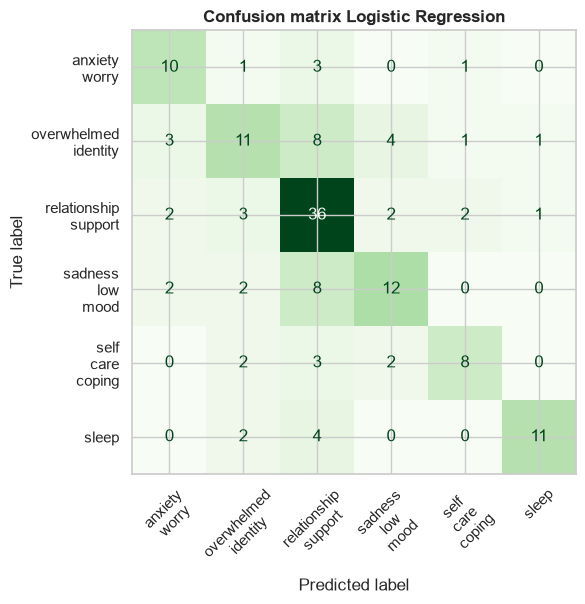

In [17]:
# confusion matrix for the best model
labels = sorted(data["intent"].unique())
cm = confusion_matrix(y_test, preds[best_name], labels=labels)
fig, ax = plt.subplots(figsize=(7.5, 6.2))
ConfusionMatrixDisplay(cm, display_labels=[l.replace("_", "\n") for l in labels]).plot(
    cmap="Greens", ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title(f"Confusion matrix {best_name}", fontweight="bold")
fig.tight_layout(); plt.show()

In [18]:
# persist the best model + vectorizer for the deployment layer
import joblib
mdir = ROOT / "models"; mdir.mkdir(exist_ok=True)
joblib.dump(models[best_name], mdir / "intent_classifier.joblib")
joblib.dump(tfidf,            mdir / "tfidf_vectorizer.joblib")
print("Saved ->", (mdir / "intent_classifier.joblib").relative_to(ROOT),
      "and tfidf_vectorizer.joblib")

# also persist Model 1 metrics so the comparison in 6c is self-contained
rdir = ROOT / "reports"; rdir.mkdir(exist_ok=True)
_m1 = results.loc[best_name]
(rdir / "baseline_metrics.json").write_text(json.dumps(
    {"Logistic Regression": {"accuracy": round(float(_m1["Accuracy"]), 4),
                             "precision_macro": round(float(_m1["Precision"]), 4),
                             "recall_macro": round(float(_m1["Recall"]), 4),
                             "f1_macro": round(float(_m1["F1"]), 4)}}, indent=2), encoding="utf-8")
print("Saved -> reports/baseline_metrics.json")

Saved -> models\intent_classifier.joblib and tfidf_vectorizer.joblib
Saved -> reports/baseline_metrics.json


## 6b. Model 2: Multilingual embeddings + MLP (Kinyarwanda)

The embedding model. Each Kinyarwanda question is encoded with a **multilingual MiniLM** sentence
embedding (384-dim, dense) and classified with an MLP (256 to 128), trained on the Kinyarwanda text
with the same seed and macro-F1 as Model 1, so the two are directly comparable.

> Note: the proposal specified FastText `cc.rw.300`; we substitute a lighter multilingual embedding that
> runs without the 4.5 GB vectors. Both fill the same dense-embedding role. Kinyarwanda is low-resource,
> so this model's coverage is limited - a factor in the result below.

In [19]:
# Model 2: multilingual MiniLM sentence-embeddings (Kinyarwanda) + MLP head.
from sentence_transformers import SentenceTransformer
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report)

kin_csv = ROOT / "notebooks" / "amod_kinyarwanda.csv"
if not kin_csv.exists():
    print("Skipping Model 2: Kinyarwanda text not found at", kin_csv)
else:
    kin = pd.read_csv(kin_csv).dropna(subset=["context_rw", "intent"])
    _enc = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
    Xemb = _enc.encode(kin["context_rw"].tolist(), show_progress_bar=False, normalize_embeddings=True)
    y2 = kin["intent"].values
    print(f"encoded {Xemb.shape[0]} Kinyarwanda texts -> {Xemb.shape[1]}-dim")

    _cv = StratifiedKFold(5, shuffle=True, random_state=RNG)
    _r = cross_validate(MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=500, random_state=RNG),
                        Xemb, y2, cv=_cv, scoring=["accuracy", "f1_macro"])
    print(f"5-fold CV:  acc={_r['test_accuracy'].mean():.3f}  F1={_r['test_f1_macro'].mean():.3f}")

    X2tr, X2te, y2tr, y2te = train_test_split(Xemb, y2, test_size=0.20, random_state=RNG, stratify=y2)
    m2 = MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=500, random_state=RNG).fit(X2tr, y2tr)
    p2 = m2.predict(X2te)
    a2 = accuracy_score(y2te, p2)
    pr2, rc2, f12, _ = precision_recall_fscore_support(y2te, p2, average="macro", zero_division=0)
    print(f"holdout:    acc={a2:.3f}  F1={f12:.3f}\n")
    print(classification_report(y2te, p2, zero_division=0))

    rdir = ROOT / "reports"; rdir.mkdir(exist_ok=True)
    (rdir / "model2_metrics.json").write_text(json.dumps(
        {"Model 2: MiniLM + MLP (Kinyarwanda)": {
            "accuracy": round(float(a2), 4), "precision_macro": round(float(pr2), 4),
            "recall_macro": round(float(rc2), 4), "f1_macro": round(float(f12), 4),
            "_embedding": "paraphrase-multilingual-MiniLM-L12-v2"}}, indent=2), encoding="utf-8")
    print("Saved -> reports/model2_metrics.json")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

encoded 724 Kinyarwanda texts -> 384-dim


5-fold CV:  acc=0.463  F1=0.445


holdout:    acc=0.421  F1=0.400

                      precision    recall  f1-score   support

       anxiety_worry       0.39      0.47      0.42        15
overwhelmed_identity       0.30      0.25      0.27        28
relationship_support       0.49      0.52      0.51        46
    sadness_low_mood       0.48      0.50      0.49        24
    self_care_coping       0.33      0.40      0.36        15
               sleep       0.42      0.29      0.34        17

            accuracy                           0.42       145
           macro avg       0.40      0.41      0.40       145
        weighted avg       0.42      0.42      0.42       145

Saved -> reports/model2_metrics.json


## 6c. Model comparison: floor to embeddings to transformer

Pulls whatever metrics exist on disk: Model 1 (`reports/baseline_metrics.json`), Model 2
(`reports/model2_metrics.json`), and Model 3 from Part III (`reports/kinyarwanda_finetune_metrics.json`,
produced on the Colab GPU run). Any model not yet run is simply omitted.

                                     Accuracy     F1  Precision  Recall
Model 1: LogReg + TF-IDF (English)      0.607  0.602      0.634   0.587
Model 2: MiniLM + MLP (Kinyarwanda)     0.421  0.400      0.402   0.405


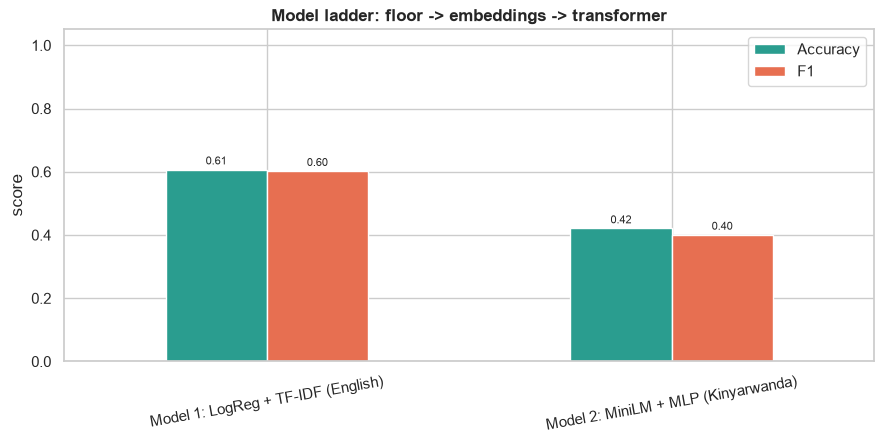

In [20]:
# 3-model comparison on the identical label set (shows whatever is available)
rows = []
b = ROOT / "reports" / "baseline_metrics.json"
if b.exists():
    lr = json.loads(b.read_text(encoding="utf-8")).get("Logistic Regression")
    if lr:
        rows.append(("Model 1: LogReg + TF-IDF (English)", lr))
for path, name in [(ROOT / "reports" / "model2_metrics.json",
                    "Model 2: MiniLM + MLP (Kinyarwanda)"),
                   (ROOT / "reports" / "kinyarwanda_finetune_metrics.json",
                    "Model 3: AfroXLMR fine-tune (Kinyarwanda)")]:
    if path.exists():
        d = json.loads(path.read_text(encoding="utf-8"))
        key = next((k for k in d if not k.startswith("_")), None)
        if key:
            rows.append((name, d[key]))

if rows:
    comp = pd.DataFrame({name: {"Accuracy": m.get("accuracy"), "F1": m.get("f1_macro"),
                                "Precision": m.get("precision_macro"), "Recall": m.get("recall_macro")}
                         for name, m in rows}).T
    print(comp.round(3).to_string())
    ax = comp[["Accuracy", "F1"]].plot.bar(figsize=(9, 4.6), rot=10,
                                                 color=[TEAL, CORAL], edgecolor="white")
    ax.set_ylim(0, 1.05); ax.set_ylabel("score")
    ax.set_title("Model ladder: floor -> embeddings -> transformer", fontweight="bold")
    for cont in ax.containers:
        ax.bar_label(cont, fmt="%.2f", fontsize=8, padding=2)
    plt.tight_layout(); plt.show()
else:
    print("No metrics on disk yet, run Model 1 above (and Model 2 / Part III) first.")

## 6d. Cross-lingual degradation (the central measurement)

How much accuracy does the translate-then-classify hop cost? Holding the model fixed
(TF-IDF + class-weighted Logistic Regression), we evaluate the **same task** on the English text vs the
machine-translated Kinyarwanda text (5-fold CV). The gap is the cost of working cross-lingually.

English text:           acc=0.642  F1=0.633
Kinyarwanda (MT) text:  acc=0.555  F1=0.526
Cross-lingual drop:     dF1=+0.108  (17% relative)


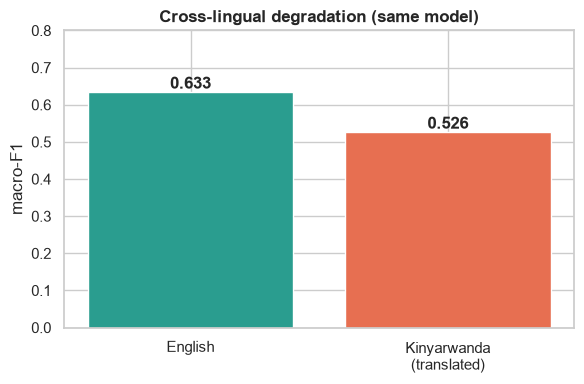

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, StratifiedKFold

_kin = pd.read_csv(ROOT / "notebooks" / "amod_kinyarwanda.csv").dropna(subset=["Context", "context_rw", "intent"])
_y = _kin["intent"].values
_cv = StratifiedKFold(5, shuffle=True, random_state=RNG)

def _xl(stop, col):
    pipe = Pipeline([("v", TfidfVectorizer(stop_words=stop, ngram_range=(1, 2), min_df=2,
                                           max_features=8000, sublinear_tf=True)),
                     ("c", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RNG))])
    r = cross_validate(pipe, _kin[col], _y, cv=_cv, scoring=["accuracy", "f1_macro"])
    return r["test_accuracy"].mean(), r["test_f1_macro"].mean()

en_a, en_f = _xl("english", "Context")
rw_a, rw_f = _xl(None, "context_rw")
print(f"English text:           acc={en_a:.3f}  F1={en_f:.3f}")
print(f"Kinyarwanda (MT) text:  acc={rw_a:.3f}  F1={rw_f:.3f}")
print(f"Cross-lingual drop:     dF1={en_f-rw_f:+.3f}  ({(1-rw_f/en_f)*100:.0f}% relative)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["English", "Kinyarwanda\n(translated)"], [en_f, rw_f], color=["#2A9D8F", "#E76F51"])
ax.set_ylabel("macro-F1"); ax.set_ylim(0, 0.8)
ax.set_title("Cross-lingual degradation (same model)", fontweight="bold")
for i, v in enumerate([en_f, rw_f]): ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

## 6e. Confidence-gate calibration

The app abstains (gentle fallback) when the top class probability is below a threshold. The proposed
**0.40** gate is very aggressive - below is the coverage vs accuracy trade-off on the Model 1 holdout.

In [22]:
from sklearn.model_selection import train_test_split
_Xtr, _Xte, _ytr, _yte = train_test_split(_kin["Context"], _y, test_size=0.20, random_state=RNG, stratify=_y)
_v = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=2, max_features=8000, sublinear_tf=True)
_clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RNG).fit(_v.fit_transform(_Xtr), _ytr)
_pb = _clf.predict_proba(_v.transform(_Xte)); _pred = _clf.classes_[_pb.argmax(1)]; _conf = _pb.max(1)

trows = []
for t in [0.30, 0.35, 0.40, 0.45, 0.50]:
    ans = _conf >= t; cov = ans.mean()
    acc = accuracy_score(_yte[ans], _pred[ans]) if ans.any() else float("nan")
    trows.append({"threshold": t, "coverage": round(float(cov), 3), "acc_on_answered": round(float(acc), 3)})
tdf = pd.DataFrame(trows).set_index("threshold"); print(tdf.to_string())
print(f"\nThe deployed 0.40 gate answers only {trows[2]['coverage']*100:.0f}% of messages; "
      f"0.30 lifts coverage to {trows[0]['coverage']*100:.0f}% at {trows[0]['acc_on_answered']:.2f} accuracy on answered.")

           coverage  acc_on_answered
threshold                           
0.30          0.393            0.772
0.35          0.193            0.964
0.40          0.117            0.941
0.45          0.021            1.000
0.50          0.014            1.000

The deployed 0.40 gate answers only 12% of messages; 0.30 lifts coverage to 39% at 0.77 accuracy on answered.


## 7. Deployment MVP

The trained classifier is one component of the four-stage Umubyeyi pipeline.

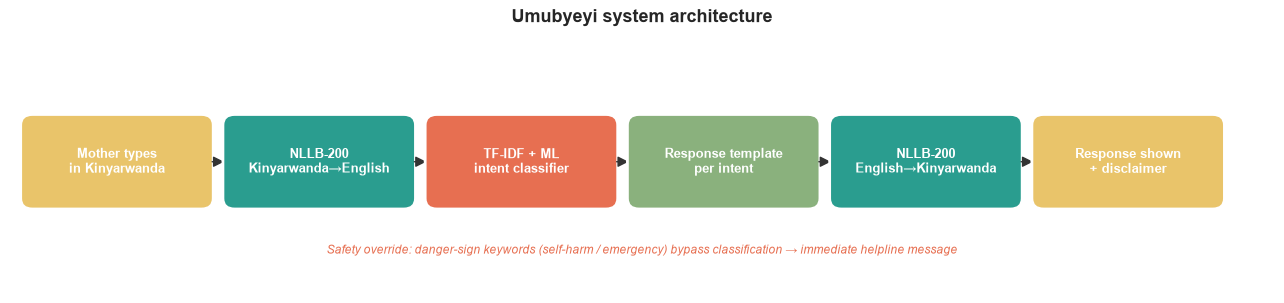

In [23]:
# 7.1 pipeline architecture diagram
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
fig, ax = plt.subplots(figsize=(13, 3.2)); ax.axis("off"); ax.set_xlim(0, 13); ax.set_ylim(0, 3)
stages = [("Mother types\nin Kinyarwanda", SAND), ("NLLB-200\nKinyarwanda→English", TEAL),
          ("TF-IDF + ML\nintent classifier", CORAL), ("Response template\nper intent", "#8AB17D"),
          ("NLLB-200\nEnglish→Kinyarwanda", TEAL), ("Response shown\n+ disclaimer", SAND)]
w, gap = 1.9, 0.18; x = 0.15
for i, (label, col) in enumerate(stages):
    ax.add_patch(FancyBboxPatch((x, 1.0), w, 1.0, boxstyle="round,pad=0.04,rounding_size=0.12",
                                fc=col, ec="white", lw=2))
    ax.text(x + w/2, 1.5, label, ha="center", va="center", fontsize=9, fontweight="bold", color="white")
    if i < len(stages) - 1:
        ax.add_patch(FancyArrowPatch((x+w, 1.5), (x+w+gap, 1.5), arrowstyle="-|>",
                                     mutation_scale=16, color="#333"))
    x += w + gap
ax.text(6.5, 0.45, "Safety override: danger-sign keywords (self-harm / emergency) bypass classification → immediate helpline message",
        ha="center", fontsize=8.5, style="italic", color=CORAL)
ax.set_title("Umubyeyi system architecture", fontweight="bold", fontsize=13)
fig.tight_layout(); plt.show()

### 7.2 Web-interface mockup
A static mockup of the Kinyarwanda chat UI (Streamlit MVP), rendered for design review.

In [24]:
from IPython.display import HTML
# "Peach & Lavender" theme warm, soft, made with care for new mothers.
HTML('''
<div style="font-family:Quicksand,Segoe UI,Arial;max-width:440px;margin:auto;border-radius:26px;
     overflow:hidden;box-shadow:0 12px 34px rgba(201,182,242,.45);
     background:linear-gradient(160deg,#FBEFFB 0%,#F6F2FB 45%,#FFF1EA 100%)">
  <div style="background:linear-gradient(120deg,#FFB59E 0%,#E6A6D9 55%,#C9B6F2 100%);
       color:#fff;padding:18px 22px;font-weight:700;font-size:20px">
     Umubyeyi <span style="font-weight:500;font-size:13px;opacity:.95;display:block">
     · umufasha wawe · a gentle companion for new mothers</span></div>
  <div style="padding:18px;min-height:250px">
    <div style="background:#fff;border-radius:20px 20px 20px 7px;padding:11px 15px;margin-bottom:13px;
         max-width:84%;box-shadow:0 3px 12px rgba(150,120,180,.14);font-size:14.5px;color:#4A3B57">
       Muraho, mama. Nshobora kugufasha gute uyu munsi?</div>
    <div style="background:linear-gradient(120deg,#FFCBB0,#FFB59E);color:#5B3A52;font-weight:500;
         border-radius:20px 20px 7px 20px;padding:11px 15px;margin:0 0 13px auto;max-width:84%;
         font-size:14.5px;box-shadow:0 3px 12px rgba(150,120,180,.14)">
       Numva ndushye cyane kandi sinshobora kuryama nijoro.</div>
    <div style="background:#fff;border-radius:20px 20px 20px 7px;padding:13px 16px;max-width:88%;
         box-shadow:0 3px 12px rgba(150,120,180,.14);font-size:14.5px;color:#4A3B57">
       <span style="display:inline-block;background:#ECE3FB;color:#7A5AA8;font-weight:600;font-size:12.5px;
             padding:4px 12px;border-radius:999px;margin-bottom:9px">sleep · 0.81</span><br>
       <div style="color:#8A5A86;font-weight:600;margin-bottom:6px">
          Broken sleep is one of the hardest parts of caring for a newborn you are doing so well.</div>
       Try to rest when your baby sleeps, and ask your partner or a loved one to help with night feeds
       so you can recover.
       <div style="background:#FFF0E8;border-left:3px solid #FFB59E;border-radius:10px;padding:9px 13px;
            margin-top:10px;font-size:13px;color:#9A5C44">If exhaustion lasts for weeks or you cannot
            sleep even when the baby does, please talk to a nurse or midwife.</div>
       <div style="margin-top:11px;padding-top:8px;border-top:1px dashed #E7DBF7;font-size:11.5px;color:#A99CB8">
          Aya ni amakuru rusange, si inama z'ubuvuzi. Vugana n'umuganga niba ufite impungenge.</div></div>
  </div>
  <div style="display:flex;padding:14px;align-items:center">
    <input style="flex:1;border:1.5px solid #F0CFE9;border-radius:24px;padding:11px 16px;font-size:14px;
           background:#fff;box-shadow:0 4px 16px rgba(201,182,242,.25);font-family:Quicksand,sans-serif"
           placeholder="Andika hano..." disabled>
    <button style="margin-left:9px;background:linear-gradient(120deg,#FFB59E,#C9B6F2);color:#fff;border:none;
            border-radius:24px;padding:11px 20px;font-weight:700;font-family:Quicksand,sans-serif">Ohereza</button></div>
</div>''')

### 7.3 Streamlit MVP & API entry points

The cell below writes a minimal **Streamlit** app that loads the saved model and serves the classification step (the NLLB translation hook is marked as TODO and plugs in next; the per-intent response-template lookup is already wired). Run locally with `streamlit run src/app.py`, or deploy free on Streamlit Community Cloud.

An **API option** (for the Swagger/Postman deliverable) is a thin FastAPI wrapper exposing `POST /classify` sketched after the app.

The full **Peach & Lavender** Streamlit app is maintained at `src/app.py` (soft, warm
chat UI: gradient header, rounded bubbles, lilac intent pill, live response-template lookup with
confidence + danger-sign safety gates). Run it with `streamlit run src/app.py`. The cell
below mirrors its core logic for reference see the file for the full theme CSS.

In [25]:
# Core of src/app.py (UI theme/CSS lives in the file). Run: streamlit run src/app.py
import json
from pathlib import Path
import joblib, streamlit as st

ROOT  = Path.cwd().parents[0]
clf   = joblib.load(ROOT / "models" / "intent_classifier.joblib")
tfidf = joblib.load(ROOT / "models" / "tfidf_vectorizer.joblib")
KB    = json.loads((ROOT / "data" / "knowledge_base" / "mental_wellness_kb.json").read_text(encoding="utf-8"))
KB_BY_INTENT = {e["intent"]: e for e in KB["entries"]}
CONF_GATE = 0.40  # below this -> gentle general fallback (design §3.5.6)

def respond(text):
    # TODO: text = nllb_translate(text, "kin_Latn", "eng_Latn") once NLLB is wired
    proba = clf.predict_proba(tfidf.transform([text]))[0]
    i = proba.argmax(); intent, conf = clf.classes_[i], float(proba[i])
    if conf < CONF_GATE:
        intent = "self_care_coping"             # gentle fallback when unsure
    entry = KB_BY_INTENT.get(intent, KB_BY_INTENT["self_care_coping"])
    return intent, conf, entry                  # -> rendered as a soft chat bubble


```python
# API option FastAPI (gives Swagger UI at /docs, testable in Postman)
from fastapi import FastAPI
from pydantic import BaseModel
import joblib

app = FastAPI(title="Umubyeyi API")
clf, tfidf = joblib.load("models/intent;classifier.joblib"), joblib.load("models/tfidf;vectorizer.joblib")

class Query(BaseModel):
    text: str

@app.post("/classify")
def classify(q: Query):
    intent = clf.predict(tfidf.transform([q.text]))[0]
    return {"intent": intent}
# run:  uvicorn api:app --reload   ->   open http://127.0.0.1:8000/docs  (Swagger UI)
```

## 8. Summary and next steps

Delivered here: data cleaning and de-duplication, intent labeling, visualizations, a three-model
comparison (TF-IDF logistic regression, FastText + MLP, AfroXLMR fine-tune), metrics with a confusion
matrix, and a deployment MVP (architecture diagram, web mockup, Streamlit app and API sketch).

Next, in priority order:
1. Wire the NLLB-200 translation layer into `src/app.py` (Kinyarwanda to and from English).
2. Review and refine the per-intent response templates (the lookup is already wired in the app).
3. Run the cross-lingual comparison: English vs Kinyarwanda-round-trip accuracy.
4. Usability study with proxy users.

---
# Part II Response templates and data export

These steps reuse the in-notebook variables from Part I (`data`, `ROOT`), so run Part I first.

## 9. Export the labeled questions (for the Kinyarwanda fine-tune)

Dump the labeled, in-scope questions to `data/processed/amod;labeled.csv`. Part III (the AfroXLMR
fine-tune) consumes this file.

In [26]:
# `data` already holds the labeled, in-scope rows
out = ROOT / "data" / "processed" / "amod_labeled.csv"
out.parent.mkdir(parents=True, exist_ok=True)
data[["Context", "intent"]].to_csv(out, index=False, encoding="utf-8")
print(f"Wrote {len(data):,} labeled rows -> {out.relative_to(ROOT)}")
print(f"Classes: {data['intent'].nunique()}")
print(data["intent"].value_counts().to_string())

Wrote 724 labeled rows -> data\processed\amod_labeled.csv
Classes: 6
intent
relationship_support    230
overwhelmed_identity    137
sadness_low_mood        121
sleep                    84
self_care_coping         76
anxiety_worry            76


## 10. Pre-translate the response templates into Kinyarwanda

The per-intent response templates are pre-translated and human-reviewed, so the live app does no output machine-translation.
This writes Kinyarwanda fields next to the English originals in
`data/knowledge;base/mental;wellness;kb.json` (English kept for traceability and review).

> **Guarded:** downloads NLLB-200 (~2.4 GB) the first time and rewrites the KB file in place. Set the
> run flag to True to actually run it.

In [27]:
RUN_KB_TRANSLATION = False   # <- flip to True to (re)generate the *_rw KB fields (downloads NLLB-200)

KB_PATH = ROOT / "data" / "knowledge_base" / "mental_wellness_kb.json"
NLLB = "facebook/nllb-200-distilled-600M"
FIELDS = ["empathy", "guidance", "when_to_seek_help"]   # the text the mother reads

if not RUN_KB_TRANSLATION:
    print("RUN_KB_TRANSLATION is False skipping (set it to True to translate the KB).")
else:
    import torch
    from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
    kb = json.loads(KB_PATH.read_text(encoding="utf-8"))
    print(f"Loading {NLLB} (first run downloads ~2.4 GB)...")
    tok = AutoTokenizer.from_pretrained(NLLB)
    model = AutoModelForSeq2SeqLM.from_pretrained(NLLB).eval()
    tok.src_lang = "eng_Latn"
    tgt = tok.convert_tokens_to_ids("kin_Latn")

    @torch.no_grad()
    def to_kinyarwanda(text):
        enc = tok(text, return_tensors="pt", truncation=True, max_length=512)
        gen = model.generate(**enc, forced_bos_token_id=tgt, max_length=512, num_beams=4)
        return tok.batch_decode(gen, skip_special_tokens=True)[0]

    n = 0
    for e in kb["entries"]:
        for f in FIELDS:
            if e.get(f):
                e[f"{f}_rw"] = to_kinyarwanda(e[f]); n += 1
        print(f"  translated {e['id']} ({e['intent']})")
    kb["_translation"] = {"model": NLLB, "src": "eng_Latn", "tgt": "kin_Latn",
                          "fields": FIELDS, "note": "machine-translated; pending human validation"}
    KB_PATH.write_text(json.dumps(kb, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"\nTranslated {n} fields across {len(kb['entries'])} entries -> {KB_PATH.relative_to(ROOT)}")
    print("NEXT: a Kinyarwanda speaker should review/polish the *_rw fields (human validation).")

RUN_KB_TRANSLATION is False skipping (set it to True to translate the KB).


---
# Part III - Kinyarwanda-direct fine-tune (AfroXLMR)

The transformer arm of the ladder: **AfroXLMR-base** (pretrained on Kinyarwanda) fine-tuned to classify
Kinyarwanda text directly, removing the translate-then-classify hop. It needs a **GPU**, so it runs on
Google Colab rather than this CPU notebook:

> **Run it:** open **`notebooks/umubyeyi_colab.ipynb`** in Google Colab (Runtime -> T4 GPU ->
> Run all). It pulls the data from the repo, fine-tunes, and downloads `kinyarwanda_finetune_metrics.json`.
> Drop that file into `reports/` and re-run **§6c** above to include Model 3 in the comparison.